#### ① 导入库与加载数据

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
X_train = X_train[..., tf.newaxis]
X_test = X_test[..., tf.newaxis]

#### ② 定义构建模型的函数

In [16]:
def build_model(activation = 'sigmoid'):
    model = models.Sequential([layers.Conv2D(6, 5, activation = activation, input_shape = (28, 28, 1)),
                               layers.MaxPooling2D(2, 2),
                               layers.Conv2D(16, 5, activation = activation),
                               layers.MaxPooling2D(2, 2),
                               layers.Flatten(),
                               layers.Dense(120, activation = activation),
                               layers.Dense(84, activation = activation),
                               layers.Dense(10, activation = 'softmax'),
    ])
    return model


#### ③ 训练并记录两个模型的历史

In [17]:
history_sigmoid = None
history_relu = None

# 训练 ReLu版本
model_relu = build_model('relu')
model_relu.compile(optimizer = 'adam',
                      loss = 'sparse_categorical_crossentropy',
                      metrics = ['accuracy'])
print("\n===== 训练 ReLU 模型 =====")
history_relu = model_relu.fit(X_train, y_train, 
                              batch_size = 64, epochs = 5, 
                              validation_split = 0.1, verbose = 1)

# 训练 Sigmoid 版本
model_sigmoid = build_model('sigmoid')
model_sigmoid.compile(optimizer = 'adam',
                      loss = 'sparse_categorical_crossentropy',
                      metrics = ['accuracy'])
print("===== 训练 Sigmoid 模型 =====")
history_sigmoid = model_sigmoid.fit(X_train, y_train, 
                                    batch_size = 64, epochs = 5, 
                                    validation_split = 0.1, verbose = 1)



===== 训练 ReLU 模型 =====
Epoch 1/5


d:\DevTools\Miniconda3\envs\nn-history\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9230 - loss: 0.2553 - val_accuracy: 0.9778 - val_loss: 0.0787
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9759 - loss: 0.0774 - val_accuracy: 0.9820 - val_loss: 0.0646
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9827 - loss: 0.0555 - val_accuracy: 0.9798 - val_loss: 0.0645
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9859 - loss: 0.0440 - val_accuracy: 0.9875 - val_loss: 0.0454
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9884 - loss: 0.0358 - val_accuracy: 0.9887 - val_loss: 0.0369
===== 训练 Sigmoid 模型 =====
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6696 - loss: 1.0488 - val_accuracy: 0.9345 - val_loss: 0.2479
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9397 - loss: 0.2054 - val_accuracy: 0.9640 - val_loss: 0.1219
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9621 - loss: 0.1251 - val_accu

#### ④ 绘制训练曲线进行对比

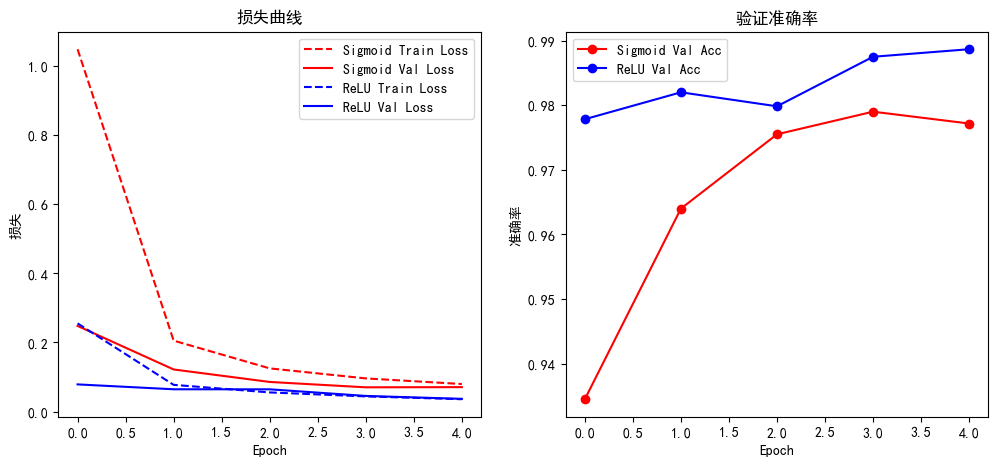

In [18]:
plt.figure(figsize=(12,5))

# 训练损失对比
plt.subplot(1,2,1)
plt.plot(history_sigmoid.history['loss'], 'r--', label='Sigmoid Train Loss')
plt.plot(history_sigmoid.history['val_loss'], 'r-', label='Sigmoid Val Loss')
plt.plot(history_relu.history['loss'], 'b--', label='ReLU Train Loss')
plt.plot(history_relu.history['val_loss'], 'b-', label='ReLU Val Loss')
plt.xlabel('Epoch')
plt.ylabel('损失')
plt.legend()
plt.title('损失曲线')

# 验证准确率对比
plt.subplot(1,2,2)
plt.plot(history_sigmoid.history['val_accuracy'], 'r-o', label='Sigmoid Val Acc')
plt.plot(history_relu.history['val_accuracy'], 'b-o', label='ReLU Val Acc')
plt.xlabel('Epoch')
plt.ylabel('准确率')
plt.legend()
plt.title('验证准确率')

plt.show()

In [19]:
# # 极简测试
# import tensorflow as tf
# tf.keras.backend.clear_session()

# model = tf.keras.Sequential([
#     tf.keras.layers.Flatten(input_shape=(28,28,1)),
#     tf.keras.layers.Dense(10, activation='relu'),  # 只有一层 ReLU
#     tf.keras.layers.Dense(10, activation='softmax')
# ])
# model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# model.fit(X_train, y_train, batch_size=64, epochs=2, validation_split=0.1)